In [12]:
import math
import matplotlib.pyplot as plt

In [13]:
data = [
    ['RollNo','Age','Income','Student','Credit Rating','Buys Computer'],
    [1,'Young','High','No','Fair','No'],
    [2,'Young','High','No','Excellent','No'],
    [3,'Middle Aged','High','No','Fair','Yes'],
    [4,'Senior','Medium','No','Fair','Yes'],
    [5,'Senior','Low','Yes','Fair','Yes'],
    [6,'Senior','Low','Yes','Excellent','No'],
    [7,'Middle Aged','Low','Yes','Excellent','Yes'],
    [8,'Young','Medium','No','Fair','No'],
    [9,'Young','Low','Yes','Fair','Yes'],
    [10,'Senior','Medium','Yes','Fair','Yes'],
    [11,'Young','Medium','Yes','Excellent','Yes'],
    [12,'Middle Aged','Medium','No','Excellent','Yes'],
    [13,'Middle Aged','High','Yes','Fair','Yes'],
    [14,'Senior','Medium','No','Excellent','No']
]


dataset = []
features = data[0][1:-1]
for row in data[1:]:
    dataset.append(row[1:])

In [14]:
import math

def calculate_entropy(data):
    count = {}
    total = len(data)

    for row in data:
        label = row[-1]
        count[label] = count.get(label, 0) + 1

    entropy = 0

    for c in count.values():
        p = c / total
        entropy -= p * math.log2(p)

    return entropy

In [15]:
def divide_dataset(records, feature_index, feature_value):

    subset = []

    for row in records:

        if row[feature_index] == feature_value:

            new_row = row[:feature_index] + row[feature_index+1:]

            subset.append(new_row)

    return subset

In [16]:
def calculate_information_gain(data, feature_index):

    total_entropy = calculate_entropy(data)

    values = []

    for row in data:
        if row[feature_index] not in values:
            values.append(row[feature_index])

    weighted_entropy = 0

    for value in values:
        subset = divide_dataset(data, feature_index, value)
        weighted_entropy += (len(subset) / len(data)) * calculate_entropy(subset)

    return total_entropy - weighted_entropy

In [17]:
def calculate_gini(data):

    count = {}
    total = len(data)

    for row in data:
        label = row[-1]
        count[label] = count.get(label, 0) + 1

    gini = 1

    for c in count.values():
        p = c / total
        gini -= p ** 2

    return gini

In [18]:
def calculate_gini_gain(data, feature_index):

    total_gini = calculate_gini(data)

    values = []

    for row in data:
        if row[feature_index] not in values:
            values.append(row[feature_index])

    weighted_gini = 0

    for value in values:
        subset = divide_dataset(data, feature_index, value)
        weighted_gini += (len(subset) / len(data)) * calculate_gini(subset)

    return total_gini - weighted_gini

In [19]:
def calculate_split_info(data, feature_index):

    values = []

    for row in data:
        if row[feature_index] not in values:
            values.append(row[feature_index])

    split_info = 0

    for value in values:

        count = 0

        for row in data:
            if row[feature_index] == value:
                count += 1

        p = count / len(data)

        split_info -= p * math.log2(p)

    return split_info

In [20]:
def calculate_gain_ratio(data, feature_index):

    gain = calculate_information_gain(data, feature_index)

    split_info = calculate_split_info(data, feature_index)

    if split_info == 0:
        return 0

    return gain / split_info

In [42]:
gain_values = []

for i in range(len(features)):
    gain = calculate_information_gain(dataset, i)
    gain_values.append(gain)
print("Features :",features)
print("Information Gain :",gain_values)

Features : ['Age', 'Income', 'Student', 'Credit Rating']
Information Gain : [0.24674981977443933, 0.02922256565895487, 0.15183550136234159, 0.04812703040826949]


In [41]:
gain_values = []

for i in range(len(features)):
    gain = calculate_gini_gain(dataset, i)
    gain_values.append(gain)
print("Features :",features)
print("Gini Index :",gain_values)

Features : ['Age', 'Income', 'Student', 'Credit Rating']
Gini Index : [0.11632653061224485, 0.018707482993197244, 0.09183673469387743, 0.030612244897959162]


In [24]:
gain_ratio_values = []

for i in range(len(features)):

    gain_ratio = calculate_gain_ratio(dataset, i)

    gain_ratio_values.append(gain_ratio)

print("Features :", features)
print("Gain Ratio :", gain_ratio_values)

Features : ['Age', 'Income', 'Student', 'Credit Rating']
Gain Ratio : [0.15642756242117528, 0.018772646222418813, 0.15183550136234159, 0.048848615511520824]


In [25]:
def find_majority_class(records):

    frequency = {}

    for row in records:
        label = row[-1]
        frequency[label] = frequency.get(label, 0) + 1

    return max(frequency, key=frequency.get)

In [26]:
def create_decision_tree(records, feature_list):

    labels = []

    for row in records:
        labels.append(row[-1])

    if labels.count(labels[0]) == len(labels):
        return labels[0]

    if len(feature_list) == 0:
        return find_majority_class(records)

    best_gain = -1
    best_feature = -1

    for i in range(len(feature_list)):
        gain = calculate_information_gain(records, i)

        if gain > best_gain:
            best_gain = gain
            best_feature = i

    tree = {feature_list[best_feature]: {}}

    values = []

    for row in records:
        if row[best_feature] not in values:
            values.append(row[best_feature])

    for value in values:

        subset = divide_dataset(records, best_feature, value)

        new_features = feature_list[:best_feature] + feature_list[best_feature+1:]

        subtree = create_decision_tree(subset, new_features)

        tree[feature_list[best_feature]][value] = subtree

    return tree

In [27]:
def create_decision_tree(records, feature_list):

    labels = []

    for row in records:
        labels.append(row[-1])

    if labels.count(labels[0]) == len(labels):
        return labels[0]

    if len(feature_list) == 0:
        return find_majority_class(records)

    best_gain = -1
    best_feature = -1

    for i in range(len(feature_list)):
        gain = calculate_gini_gain(records, i)
        if gain > best_gain:
            best_gain = gain
            best_feature = i

    tree = {feature_list[best_feature]: {}}

    values = []

    for row in records:
        if row[best_feature] not in values:
            values.append(row[best_feature])

    for value in values:

        subset = divide_dataset(records, best_feature, value)

        new_features = feature_list[:best_feature] + feature_list[best_feature+1:]

        subtree = create_decision_tree(subset, new_features)

        tree[feature_list[best_feature]][value] = subtree

    return tree

In [28]:
def create_decision_tree(records, feature_list):

    labels = []

    for row in records:
        labels.append(row[-1])

    if labels.count(labels[0]) == len(labels):
        return labels[0]

    if len(feature_list) == 0:
        return find_majority_class(records)

    best_gain = -1
    best_feature = -1

    for i in range(len(feature_list)):
        gain = calculate_gain_ratio(records, i)
        if gain > best_gain:
            best_gain = gain
            best_feature = i

    tree = {feature_list[best_feature]: {}}

    values = []

    for row in records:
        if row[best_feature] not in values:
            values.append(row[best_feature])

    for value in values:

        subset = divide_dataset(records, best_feature, value)

        new_features = feature_list[:best_feature] + feature_list[best_feature+1:]

        subtree = create_decision_tree(subset, new_features)

        tree[feature_list[best_feature]][value] = subtree

    return tree

In [29]:
def display_tree(tree, indent=""):

    if not isinstance(tree, dict):
        print(indent + "Leaf :", tree)
        return

    for feature, branches in tree.items():

        print(indent + "Root ->", feature)

        for value, subtree in branches.items():

            print(indent + "|--", value)

            display_tree(subtree, indent + "    ")

In [30]:
decision_tree = create_decision_tree(dataset, features)

print("Decision Tree\n")

display_tree(decision_tree)

Decision Tree

Root -> Age
|-- Young
    Root -> Student
    |-- No
        Leaf : No
    |-- Yes
        Leaf : Yes
|-- Middle Aged
    Leaf : Yes
|-- Senior
    Root -> Credit Rating
    |-- Fair
        Leaf : Yes
    |-- Excellent
        Leaf : No


In [31]:
def predict(tree, feature_names, sample):

    if not isinstance(tree, dict):
        return tree

    root = list(tree.keys())[0]

    index = feature_names.index(root)

    value = sample[index]

    if value not in tree[root]:
        return "Unknown"

    new_sample = sample[:index] + sample[index+1:]

    new_features = feature_names[:index] + feature_names[index+1:]

    return predict(tree[root][value], new_features, new_sample)

In [32]:
test_data = [
    ['Young', 'High', 'Yes', 'Fair', 'Yes'],
    ['Senior', 'Low', 'No', 'Excellent', 'No'],
    ['Middle Aged', 'Medium', 'Yes', 'Fair', 'Yes'],
    ['Young', 'Medium', 'No', 'Excellent', 'No'],
    ['Senior', 'Medium', 'Yes', 'Fair', 'Yes']
]

In [33]:
actual = []
predicted = []

for row in test_data:

    sample = row[:-1]

    actual.append(row[-1])

    prediction = predict(decision_tree, features, sample)

    predicted.append(prediction)

print("Actual:", actual)
print("Predicted:", predicted)

Actual: ['Yes', 'No', 'Yes', 'No', 'Yes']
Predicted: ['Yes', 'No', 'Yes', 'No', 'Yes']


In [34]:
labels = ["Yes", "No"]

matrix = [[0,0],[0,0]]

for a, p in zip(actual, predicted):

    i = labels.index(a)
    j = labels.index(p)

    matrix[i][j] += 1

print("Confusion Matrix")

print("\tPred Yes\tPred No")
print("Actual Yes\t", matrix[0][0], "\t\t", matrix[0][1])
print("Actual No\t", matrix[1][0], "\t\t", matrix[1][1])

Confusion Matrix
	Pred Yes	Pred No
Actual Yes	 3 		 0
Actual No	 0 		 2


In [35]:
correct = 0

for a, p in zip(actual, predicted):

    if a == p:
        correct += 1

accuracy = (correct / len(actual)) * 100

print("Accuracy =", round(accuracy, 2), "%")

Accuracy = 100.0 %


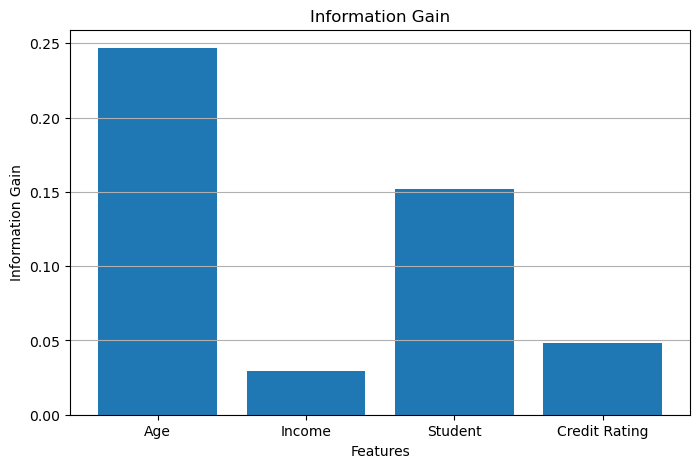

In [36]:
gain = []

for i in range(len(features)):
    gain.append(calculate_information_gain(dataset, i))

plt.figure(figsize=(8,5))
plt.bar(features, gain)
plt.title("Information Gain")
plt.xlabel("Features")
plt.ylabel("Information Gain")
plt.grid(axis='y')
plt.show()

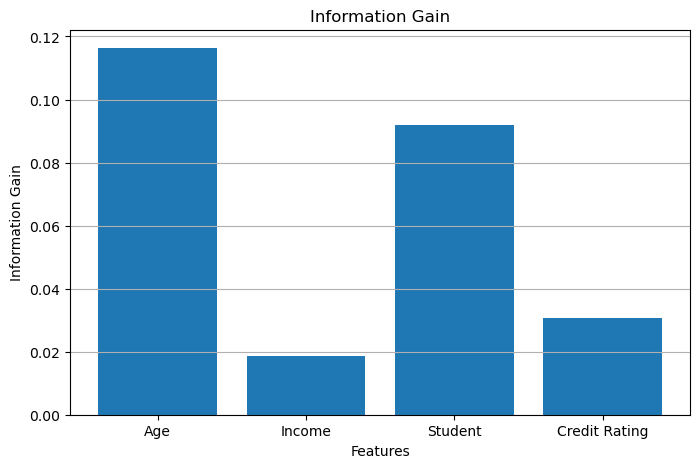

In [37]:
gain = []

for i in range(len(features)):
     gain.append(calculate_gini_gain(dataset, i))
plt.figure(figsize=(8,5))
plt.bar(features, gain)
plt.title("Information Gain")
plt.xlabel("Features")
plt.ylabel("Information Gain")
plt.grid(axis='y')
plt.show()

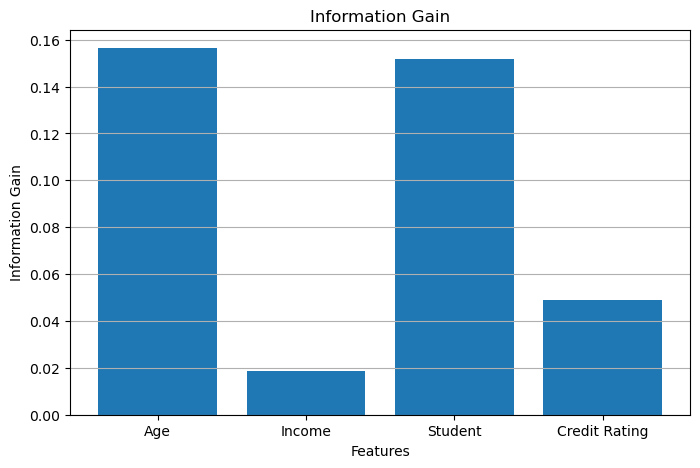

In [39]:
gain = []

for i in range(len(features)):
    gain.append(calculate_gain_ratio(dataset, i))

plt.figure(figsize=(8,5))
plt.bar(features, gain)
plt.title("Information Gain")
plt.xlabel("Features")
plt.ylabel("Information Gain")
plt.grid(axis='y')
plt.show()